In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import glob
import os

import xgboost as xgb
from xgboost import plot_importance, plot_tree
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from tqdm import tqdm
from itertools import product
import shap

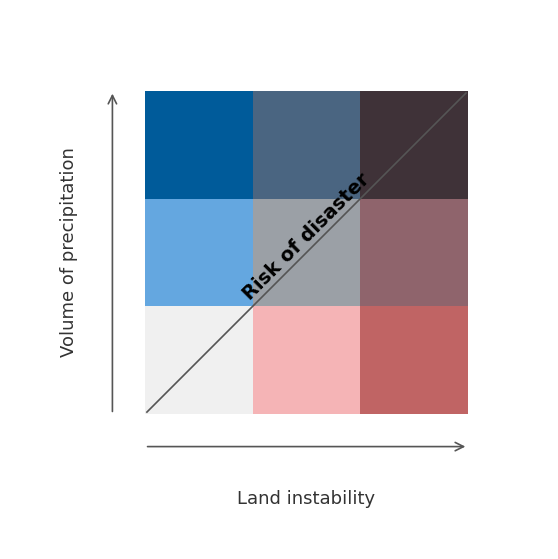

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- 1. Definição das Cores (Bivariada) ---
color_matrix_hex = [
    ["#005B9A", "#4A6581", "#3F3238"], # Topo (Precipitação Alta)
    ["#64A7E0", "#9BA0A6", "#8F646C"], # Meio
    ["#F0F0F0", "#F5B4B6", "#C06464"]  # Base (Precipitação Baixa)
]

def hex_to_rgb(hex_val):
    hex_val = hex_val.lstrip('#')
    return tuple(int(hex_val[i:i+2], 16) / 255.0 for i in (0, 2, 4))

# Organiza as cores para que a base do gráfico comece pelo branco/claro
color_matrix_rgb = [[hex_to_rgb(c) for c in row] for row in reversed(color_matrix_hex)]

# --- 2. Configuração do Canvas ---
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')

# Parâmetros de Design
block_size = 2.0
start_x, start_y = 2.5, 2.5
gray_line = '#555555' 
font_size_labels = 13
font_size_risk = 14

# --- 3. Desenhar a Matriz de Cores ---
for i in range(3):
    for j in range(3):
        ax.add_patch(patches.Rectangle(
            (start_x + j*block_size, start_y + i*block_size),
            block_size, block_size, 
            facecolor=color_matrix_rgb[i][j], 
            edgecolor='none'
        ))

# --- 4. Elementos Gráficos (Setas e Linha) ---
arrow_style = dict(arrowstyle='->', lw=1.2, color=gray_line, mutation_scale=15)

# Seta do Eixo X
ax.annotate('', xy=(start_x + 6.0, start_y - 0.6), xytext=(start_x, start_y - 0.6),
            arrowprops=arrow_style)

# Seta do Eixo Y
ax.annotate('', xy=(start_x - 0.6, start_y + 6.0), xytext=(start_x - 0.6, start_y),
            arrowprops=arrow_style)

# Linha Diagonal (Levemente menor para não tocar as extremidades)
# Recuo de 0.4 unidades em cada ponta
margin = 0.04
ax.plot([start_x + margin, start_x + 6.0 - margin], 
        [start_y + margin, start_y + 6.0 - margin], 
        color=gray_line, lw=1.2, zorder=5)

# --- 5. Textos (Centralizados e Maiores) ---

# Eixo X: Land instability
ax.text(start_x + 3.0, start_y - 1.4, 'Land instability', 
        fontsize=font_size_labels, color='#333333', ha='center', va='top')

# Eixo Y: Volume of precipitation (Centralizado na altura da matriz)
ax.text(start_x - 1.4, start_y + 3.0, 'Volume of precipitation', 
        fontsize=font_size_labels, color='#333333', ha='center', va='center', rotation=90)

# Diagonal: Risk of disaster (Centralizado no meio exato da linha)
# O texto é colocado no centro da matriz (start + 3.0) com um pequeno ajuste vertical
ax.text(start_x + 3.0, start_y + 3.3, 'Risk of disaster', 
        fontsize=font_size_risk, color='black', fontweight='bold', 
        rotation=45, ha='center', va='center',
        bbox=dict(facecolor='none', edgecolor='none', pad=0))

# Risk of disaster (Diagonal - Centralizado e acima da linha)
# O ajuste de +0.15 no y garante que ele não toque na linha
#ax.text(start_x + 3.0, start_y + 3.15, 'Risk of disaster', 
#        fontsize=font_size_risk, color='black', fontweight='bold', 
#        rotation=45, ha='center', va='bottom')




# --- 6. Exportação ---
plt.savefig("legenda_bivariada_final.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [21]:
!pip install geopandas matplotlib shapely fiona pyproj

  Using cached shapely-2.1.2-cp312-cp312-win_amd64.whl.metadata (7.1 kB)
  Using cached fiona-1.10.1-cp312-cp312-win_amd64.whl.metadata (58 kB)
  Using cached pyproj-3.7.2-cp312-cp312-win_amd64.whl.metadata (31 kB)
  Using cached pyogrio-0.12.1-cp312-cp312-win_amd64.whl.metadata (6.0 kB)
  Using cached click_plugins-1.1.1.2-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached cligj-0.7.2-py3-none-any.whl.metadata (5.0 kB)
Using cached shapely-2.1.2-cp312-cp312-win_amd64.whl (1.7 MB)
Using cached fiona-1.10.1-cp312-cp312-win_amd64.whl (24.5 MB)
Using cached pyproj-3.7.2-cp312-cp312-win_amd64.whl (6.3 MB)
Using cached click_plugins-1.1.1.2-py2.py3-none-any.whl (11 kB)
Using cached cligj-0.7.2-py3-none-any.whl (7.1 kB)
Using cached pyogrio-0.12.1-cp312-cp312-win_amd64.whl (22.9 MB)



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


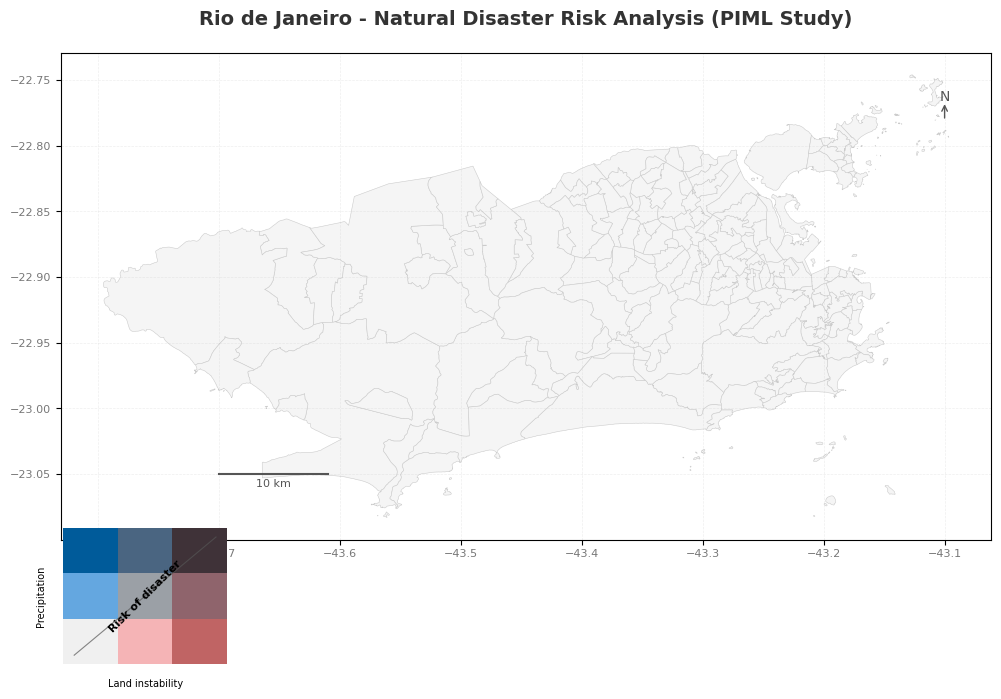

In [23]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

# --- 1. Configuração de Caminhos e Dados ---
# Usando o caminho que você forneceu
caminho_mapa = r"C:\experimento2\Comparative-study-ML-models\Limite_de_Bairros.geojson"

# Dados extraídos do seu modelo (Exemplos de bairros que aparecem no seu mapa)
# Certifique-se de que os nomes batam com a coluna 'NM_BAIRRO' ou similar do seu geojson
dados_risco = {
    "BAIRRO": ["Bangu", "Jacarepaguá", "Irajá", "Anchieta", "Méier", "Tijuca", "Centro", "Copacabana", "Barra da Tijuca", "Recreio dos Bandeirantes"],
    "Chuva": [0.35, 0.40, 0.45, 0.45, 0.60, 0.80, 0.70, 0.70, 0.50, 0.50],
    "Instabilidade": [3, 2, 3, 3, 3, 3, 3, 3, 2, 2] # 1:Low, 2:Med, 3:High
}
df_estudo = pd.DataFrame(dados_risco)

# --- 2. Carregar o GeoJSON Local ---
rj = gpd.read_file(caminho_mapa)

# --- 3. Preparação do Layout do Mapa ---
fig, ax = plt.subplots(figsize=(12, 10))

# Desenho base dos bairros (contorno discreto)
rj.plot(ax=ax, color='#F5F5F5', edgecolor='#CCCCCC', linewidth=0.4)

# Configuração de Coordenadas (Mais discretas)
ax.tick_params(axis='both', which='major', labelsize=8, labelcolor='#777777')
ax.grid(True, linestyle='--', alpha=0.2, linewidth=0.5)

# --- 4. Elementos Cartográficos ---

# Seta do Norte Minimalista
x_n, y_n = 0.95, 0.90
ax.annotate('N', xy=(x_n, y_n), xycoords='axes fraction', ha='center', fontsize=10, color='#555555')
ax.annotate('', xy=(x_n, y_n), xytext=(x_n, y_n - 0.04), xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1))

# Barra de Escala (10km) - Ajustada para a região do Rio
# 0.09 graus decimais é aproximadamente 10km nesta latitude
scale_x, scale_y = -43.70, -23.05
ax.plot([scale_x, scale_x + 0.09], [scale_y, scale_y], color='#555555', lw=1.5)
ax.text(scale_x + 0.045, scale_y - 0.01, '10 km', ha='center', fontsize=8, color='#555555')

# --- 5. Inserção da Legenda Bivariada (Customizada) ---
# Criando um eixo pequeno para a legenda dentro do mapa
ax_leg = fig.add_axes([0.12, 0.12, 0.15, 0.15]) # [esquerda, baixo, largura, altura]
ax_leg.axis('off')

# Cores da Matriz
cores_hex = [
    ["#005B9A", "#4A6581", "#3F3238"],
    ["#64A7E0", "#9BA0A6", "#8F646C"],
    ["#F0F0F0", "#F5B4B6", "#C06464"]
]

for i in range(3):
    for j in range(3):
        color = cores_hex[i][j]
        ax_leg.add_patch(patches.Rectangle((j, 2-i), 1, 1, facecolor=color))

# Textos da Legenda
ax_leg.text(1.5, -0.5, 'Land instability', ha='center', fontsize=7)
ax_leg.text(-0.5, 1.5, 'Precipitation', va='center', rotation=90, fontsize=7)
ax_leg.text(1.5, 1.5, 'Risk of disaster', ha='center', va='center', rotation=45, fontweight='bold', fontsize=8)

# Linha interna da legenda (discreta)
ax_leg.plot([0.2, 2.8], [0.2, 2.8], color='#555555', lw=0.8, alpha=0.7)

# --- 6. Finalização e Salvamento ---
ax.set_title("Rio de Janeiro - Natural Disaster Risk Analysis (PIML Study)", 
             fontsize=14, pad=20, color='#333333', fontweight='bold')

plt.savefig("mapa_risco_rio_final.png", dpi=300, bbox_inches='tight')
plt.show()

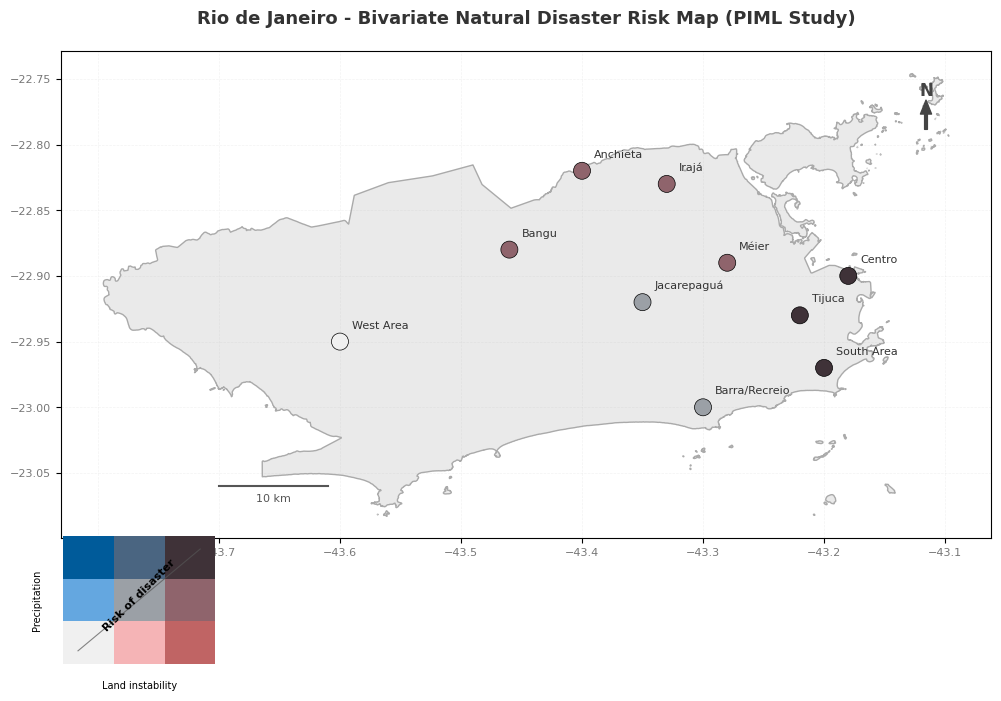

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from shapely.geometry import Point

# --- 1. Dados Estimados e Cores Bivariadas (Mantidos) ---
data_risco = {
    "BAIRRO": ["West Area", "Bangu", "Jacarepaguá", "Irajá", "Anchieta", "Méier", 
               "Tijuca", "Centro", "South Area", "Barra/Recreio"],
    "Chuva_Val": [0.15, 0.35, 0.40, 0.45, 0.45, 0.60, 0.80, 0.70, 0.70, 0.50],
    "Inst_Val": [1, 3, 2, 3, 3, 3, 3, 3, 3, 2],
    # Coordenadas aproximadas para posicionar os pontos no mapa simplificado
    "lat": [-22.95, -22.88, -22.92, -22.83, -22.82, -22.89, -22.93, -22.90, -22.97, -23.00],
    "lon": [-43.60, -43.46, -43.35, -43.33, -43.40, -43.28, -43.22, -43.18, -43.20, -43.30]
}
df_estudo = pd.DataFrame(data_risco)

# Converter DataFrame para GeoDataFrame de pontos
geometry = [Point(xy) for xy in zip(df_estudo.lon, df_estudo.lat)]
gdf_pontos = gpd.GeoDataFrame(df_estudo, geometry=geometry, crs="EPSG:4326")

# Função para atribuir cor bivariada com base nos índices (1, 2, 3)
def get_bivariate_color(chuva_val, inst_val):
    # Classificação simples em 3 níveis baseada nos valores
    c_idx = 1 if chuva_val <= 0.3 else (2 if chuva_val <= 0.6 else 3)
    i_idx = inst_val # Já está na escala 1-3
    
    cores_hex = {
        "11": "#F0F0F0", "12": "#F5B4B6", "13": "#C06464",
        "21": "#64A7E0", "22": "#9BA0A6", "23": "#8F646C",
        "31": "#005B9A", "32": "#4A6581", "33": "#3F3238"
    }
    key = f"{c_idx}{i_idx}"
    return cores_hex.get(key, "#EEEEEE")

gdf_pontos['color'] = gdf_pontos.apply(lambda row: get_bivariate_color(row['Chuva_Val'], row['Inst_Val']), axis=1)

# --- 2. Carregar e Simplificar o Mapa Local ---
caminho_geojson = r"C:\experimento2\Comparative-study-ML-models\Limite_de_Bairros.geojson"
rj_detalhado = gpd.read_file(caminho_geojson)

# DISSOLVE: Transforma todos os bairros em um único contorno da cidade
rj_outline = rj_detalhado.dissolve() 

# --- 3. Preparação do Layout ---
fig, ax = plt.subplots(figsize=(12, 10))

# A. Desenhar o contorno simplificado da cidade (Fundo)
rj_outline.plot(ax=ax, color='#EAEAEA', edgecolor='#AAAAAA', linewidth=1.0)

# B. Desenhar os pontos dos bairros com as cores de risco
# Usando marcadores maiores (markersize) para destaque
gdf_pontos.plot(ax=ax, color=gdf_pontos['color'], markersize=150, edgecolor='black', linewidth=0.5, zorder=10)

# Adicionar rótulos de texto aos pontos (discretos)
for x, y, label in zip(gdf_pontos.geometry.x, gdf_pontos.geometry.y, gdf_pontos.BAIRRO):
    ax.text(x + 0.01, y + 0.01, label, fontsize=8, color='#333333', zorder=11)

# C. Configuração de Coordenadas Discretas
ax.tick_params(axis='both', labelsize=8, labelcolor='#777777')
ax.grid(True, linestyle='--', alpha=0.15, linewidth=0.5)

# --- 4. Elementos Cartográficos ---

# A. Seta do Norte Clássica (Bússola) - Restaurada
x_n, y_n = 0.93, 0.90
# Usando um caractere especial de bússola ou desenhando com setas
ax.text(x_n, y_n, 'N', transform=ax.transAxes, ha='center', va='bottom', fontsize=12, fontweight='bold', color='#444444')
ax.annotate('', xy=(x_n, y_n), xytext=(x_n, y_n - 0.06), xycoords='axes fraction',
            arrowprops=dict(facecolor='#444444', edgecolor='#444444', width=2, headwidth=8, headlength=10))

# B. Barra de Escala Discreta (10km)
scale_x, scale_y = -43.70, -23.06
ax.plot([scale_x, scale_x + 0.09], [scale_y, scale_y], color='#555555', lw=1.5)
ax.text(scale_x + 0.045, scale_y - 0.012, '10 km', ha='center', fontsize=8, color='#555555')

# --- 5. Mini-Legenda Bivariada Customizada (Mantida e Pequena) ---
ax_leg = fig.add_axes([0.12, 0.12, 0.14, 0.14]) 
ax_leg.axis('off')

# Matriz de cores (Reutilizando a lógica anterior)
matriz_cores = [
    ["#005B9A", "#4A6581", "#3F3238"],
    ["#64A7E0", "#9BA0A6", "#8F646C"],
    ["#F0F0F0", "#F5B4B6", "#C06464"]
]
for i in range(3):
    for j in range(3):
        ax_leg.add_patch(patches.Rectangle((j, 2-i), 1, 1, facecolor=matriz_cores[i][j]))

# Textos e Diagonal da Legenda
fs_leg = 7
ax_leg.text(1.5, -0.6, 'Land instability', ha='center', fontsize=fs_leg)
ax_leg.text(-0.6, 1.5, 'Precipitation', va='center', rotation=90, fontsize=fs_leg)
ax_leg.text(1.5, 1.6, 'Risk of disaster', ha='center', va='center', rotation=45, fontweight='bold', fontsize=fs_leg+1)
ax_leg.plot([0.3, 2.7], [0.3, 2.7], color='#555555', lw=0.8, alpha=0.7)

# --- 6. Finalização ---
ax.set_title("Rio de Janeiro - Bivariate Natural Disaster Risk Map (PIML Study)", 
             fontsize=13, pad=20, color='#333333', fontweight='bold')

plt.savefig("mapa_risco_rio_simplificado.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

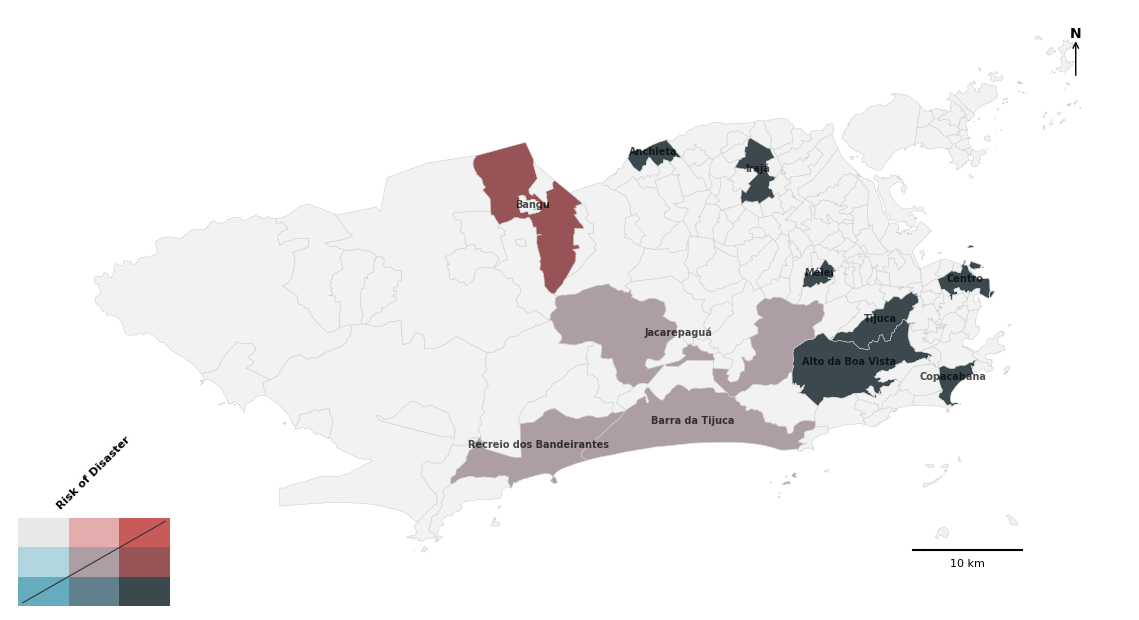

In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

# --- 1. Calibração de Cores (Cores mais fortes para bater com o original) ---
cores_bivariadas = {
    "11": "#e8e8e8", "12": "#e4acac", "13": "#c85a5a", # Baixa Precipitação
    "21": "#b0d5df", "22": "#ad9ea5", "23": "#985356", # Média Precipitação
    "31": "#64acbe", "32": "#627f8c", "33": "#3b494e"  # Alta Precipitação (Tons escuros/Tijuca)
}

# --- 2. Extração e Padronização de Dados ---
# Nomes ajustados para bater com as colunas do GeoJSON da GeoRio (geralmente maiúsculas)
dados_extracao = {
    "BAIRRO": ["BANGU", "ANCHIETA", "IRAJÁ", "JACAREPAGUÁ", "MÉIER", "ILHA DO GOVERNADOR", 
               "TIJUCA", "CENTRO", "ALTO DA BOA VISTA", "COPACABANA", "BARRA DA TIJUCA", "RECREIO DOS BANDEIRANTES"],
    "C_Idx": [2, 3, 3, 2, 3, 1, 3, 3, 3, 3, 2, 2], # Índice de Chuva (1-3)
    "I_Idx": [3, 3, 3, 2, 3, 1, 3, 3, 3, 3, 2, 2]  # Índice de Instabilidade (1-3)
}
df_piml = pd.DataFrame(dados_extracao)
df_piml['hex'] = df_piml.apply(lambda x: cores_bivariadas[f"{x.C_Idx}{x.I_Idx}"], axis=1)

# --- 3. Carregamento e Join ---
caminho = r"C:\experimento2\Comparative-study-ML-models\Limite_de_Bairros.geojson"
rj = gpd.read_file(caminho)

# Identificar coluna de nomes (Data.Rio costuma usar 'nome')
col_nome = 'nome' if 'nome' in rj.columns else rj.columns[1]
rj['nome_match'] = rj[col_nome].str.upper().str.strip()

# Pintar os bairros
rj['final_color'] = "#f2f2f2" # Cor de fundo neutra
for _, row in df_piml.iterrows():
    rj.loc[rj['nome_match'] == row['BAIRRO'], 'final_color'] = row['hex']

# --- 4. Plotagem Estilo Paper ---
fig, ax = plt.subplots(figsize=(14, 8))
rj.plot(ax=ax, color=rj['final_color'], edgecolor='#d0d0d0', linewidth=0.4)

# Adicionar Rótulos (Apenas nos bairros principais para não poluir)
for idx, row in rj.iterrows():
    if row['nome_match'] in df_piml['BAIRRO'].values:
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, row[col_nome], fontsize=7, ha='center', fontweight='bold', alpha=0.7)

# --- 5. As Três Legendas (Risco, Chuva, Landslide) ---
# [Código das legendas compactas]
ax_risk = fig.add_axes([0.1, 0.1, 0.12, 0.12])
ax_risk.axis('off')
for i in range(3):
    for j in range(3):
        ax_risk.add_patch(patches.Rectangle((j, 2-i), 1, 1, facecolor=list(cores_bivariadas.values())[i*3+j]))
ax_risk.text(1.5, 3.3, 'Risk of Disaster', ha='center', fontweight='bold', rotation=45, fontsize=8)
ax_risk.plot([0.1, 2.9], [0.1, 2.9], color='#333333', lw=0.8)

# --- 6. Norte e Escala Final ---
ax.annotate('N', xy=(0.95, 0.95), xycoords='axes fraction', ha='center', fontweight='bold')
ax.annotate('', xy=(0.95, 0.95), xytext=(0.95, 0.88), xycoords='axes fraction', arrowprops=dict(arrowstyle='->'))
ax.plot([0.8, 0.9], [0.05, 0.05], color='black', lw=1.5, transform=ax.transAxes)
ax.text(0.85, 0.02, '10 km', ha='center', transform=ax.transAxes, fontsize=8)

ax.set_axis_off()
plt.savefig("mapa_piml_v2.png", dpi=300, bbox_inches='tight')
plt.show()

In [2]:
from codecarbon import EmissionsTracker

codecarbon_output = "./codecarbon_emissions_xgboost_piml_steps.csv"

In [3]:
arquivos = {
    'Interpolado_Marambaia.csv': '0',
    'Interpolado_VilaMilitar.csv': '1',
    'Interpolado_jacarepagua.csv': '2'
}

dfs = []
for arquivo, nome_estacao in arquivos.items():
    df_temp = pd.read_csv(arquivo, sep=',', encoding='utf8')
    df_temp['estacao'] = nome_estacao
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
df = df.sort_values(by='datetime', ignore_index=True)
df['estacao'] = df['estacao'].astype(int)
colunas_umidade = [
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
    'UMIDADE RELATIVA DO AR, HORARIA (%)'
]
df[colunas_umidade] = df[colunas_umidade].clip(upper=100) #coerência física
df

export_csv = df.to_csv('dados_interpolados.csv', index=False, encoding='utf8')

Inclusão de novas variáveis - physics-informed input representation

Memória Temporal - introduz dependência temporal
    
    "Lagged variables were incorporated to capture temporal dependencies, reflecting the persistence of atmospheric conditions, which is a well-established characteristic in meteorological processes."
    1. Long-range persistence in climatological and hydrological time series: analysis, modeling and application to drought hazard assessment. https://www.sciencedirect.com/science/article/pii/S0022169497001029
    2. Time-lagged recurrence: A data-driven method to estimate the predictability of dynamical systems. https://www.pnas.org/doi/abs/10.1073/pnas.2420252122
    3. Component-Based Dynamic Factor Nowcast Model. https://papers.ssrn.com/sol3/papers.cfm?abstract_id=5230835



Acumulados - eventos extremos dependem do passado acumulado
    
    "Accumulated precipitation over temporal windows was included to represent persistence effects and cumulative moisture conditions, which are critical for rainfall formation."
    1. Atmospheric Moisture Residence Times and Cycling: Implications for Rainfall Rates and Climate Change. https://link.springer.com/article/10.1023/A:1005319109110
    2. Assessing how accumulated precipitation and long dry sequences impact the soil water storage. https://ri.conicet.gov.ar/handle/11336/92380


Tendência - registro da variação - mudanças rápidas geram instabilidade
    
    "First-order temporal differences were computed to capture short-term atmospheric variability, which is associated with instability and precipitation development."
    1. https://journals.ametsoc.org/view/journals/clim/11/3/1520-0442_1998_011_0334_satvoa_2.0.co_2.xml
    2. VARIAÇÕES DE TEMPERATURA E UMIDADE RELATIVA DO AR EM ÁREA URBANA E RURAL DURANTE O SEGMENTO TEMPORAL DE INVERNO DE 2011 EM CONTAGEM E BETIM (MG) (Variations of temperature and humidity of air in rural and urban area during the time segment...). https://revista.ufrr.br/actageo/article/view/1103
    3. https://www.researchgate.net/profile/Milla-Costa/publication/396528893_EPISODIO_DE_TEMPO_SEVERO_E_INUNDACOES_EM_BRASILIA-DF_O_AQUECIMENTO_DIURNO_E_A_TOPOGRAFIA_COMO_FATORES_DETERMINANTES_NA_ORGANIZACAO_E_DESENVOLVIMENTO_DA_CONVECCAO_PROFUNDA/links/68f162da7d9a4d4e870a3cb0/EPISODIO-DE-TEMPO-SEVERO-E-INUNDACOES-EM-BRASILIA-DF-O-AQUECIMENTO-DIURNO-E-A-TOPOGRAFIA-COMO-FATORES-DETERMINANTES-NA-ORGANIZACAO-E-DESENVOLVIMENTO-DA-CONVECCAO-PROFUNDA.pdf
    4. A new perspective on the spatio-temporal variability of soil moisture: temporal dynamics versus time-invariant contributions. https://hess.copernicus.org/articles/16/2169/2012/




Relações físicas - dew_spread - diferença entre temperatura e ponto de orvalho - indicador de saturação
    pequeno > ar saturado > maior chance de chuva e grande > ar seco
    https://www.weather.gov/arx/why_dewpoint_vs_humidity

    "The difference between air temperature and dew point temperature (dew spread) is used as an indicator of atmospheric moisture saturation, where lower values indicate conditions favorable to condensation and precipitation."

    Ref:
    1.Relationship of extreme precipitation, surface air temperature, and dew point temperature across the Tibetan Plateau. https://link.springer.com/article/10.1007/s10584-021-03076-2
    2. The relationship of atmospheric air temperature and dew point temperature to extreme rainfall. https://iopscience.iop.org/article/10.1088/1748-9326/ab2a26/meta
    3. Estimating air humidity from temperature and precipitation measures for modelling applications. https://rmets.onlinelibrary.wiley.com/doi/full/10.1002/met.258




This study adopts a physics-informed reformulation of the input space by incorporating derived variables grounded in atmospheric processes. Specifically, dew spread (temperature–dew point difference) is used as an indicator of moisture saturation, while lagged variables and accumulated precipitation capture temporal persistence effects. Additionally, first-order temporal differences are introduced to represent short-term atmospheric variability associated with instability. These transformations ensure that the model is guided by physically meaningful relationships rather than purely statistical correlations.

(a07) Spatiotemporal coherence
tendência tem relação com a dinâmica da atmosfera
acumulado ( a mamória) influencia nos eventos extremos

(a09) Interpretability
as variáveis tem significado físico e consigo explicar cada uma delas


✔ (a07) Spatiotemporal coherence
    lag → memória
    acumulado → persistência
    tendência → dinâmica
✔ (a08) Physics-based modeling
    dew spread
    ajustes físicos (temperatura/pressão)
✔ (a09) Interpretability
    variáveis com significado físico
    SHAP
👉 Isso é PIML multi-abordagem.

In [33]:
import platform
import psutil
import torch

print("OS:", platform.system(), platform.release())
print("Processor:", platform.processor())
print("RAM (GB):", round(psutil.virtual_memory().total / (1024**3), 2))

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: Not available")

OS: Windows 11
Processor: Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
RAM (GB): 15.71
GPU: Not available


In [4]:
# --------------------------------------
# PIML - INCLUSÃO DE NOVAS VARIÁVEIS
# Teste 1 - 20260406
# --------------------------------------
df_piml = df.copy()

# (dependência temporal)
# adicionando memória temporal - prec 1 hora antes e 3 horas antes. também humidade e temperatura também uma hora antes
df_piml['precip_lag_1'] = df_piml['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].shift(1)
#df_piml['precip_lag_2'] = df_piml['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].shift(2)
df_piml['precip_lag_3'] = df_piml['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].shift(3)
df_piml['humidity_lag_1'] = df_piml['UMIDADE RELATIVA DO AR, HORARIA (%)'].shift(1)
df_piml['temp_lag_1'] = df_piml['TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)'].shift(1)

# acumulados de chuva - mta relação com eventos extremos - 3h, 3h e 12h
df_piml['precip_acc_3h'] = df_piml['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].rolling(3).sum()
df_piml['precip_acc_6h'] = df_piml['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].rolling(6).sum()
df_piml['precip_acc_12h'] = df_piml['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].rolling(12).sum()

# tendÊncia - variação - causa instabilidade
df_piml['humidity_trend'] = df_piml['UMIDADE RELATIVA DO AR, HORARIA (%)'] - df_piml['humidity_lag_1']
df_piml['temp_trend'] = df_piml['TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)'] - df_piml['temp_lag_1']


# relação fisica - diferença entre a temperatura atual e o ponto de orvalho
# o ponto de orvalho é a temperatura na qual o ar ficaria saturado (100% de umidade)
# ou seja, é o momento em que o vapor dágua começa a condensar, formando nuvens e podendo gerar chuva
df_piml['dew_spread'] = df_piml['TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)'] - df_piml['TEMPERATURA DO PONTO DE ORVALHO (°C)']

#df_piml['humidity_temp'] = df_piml['UMIDADE RELATIVA DO AR, HORARIA (%)'] * df_piml['TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)']
#df_piml['instability'] = df_piml['UMIDADE RELATIVA DO AR, HORARIA (%)'] / df_piml['PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)']

# LIMPEZA
df_piml = df_piml.dropna()

df_piml.head()

,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),...,precip_lag_1,precip_lag_3,humidity_lag_1,temp_lag_1,precip_acc_3h,precip_acc_6h,precip_acc_12h,humidity_trend,temp_trend,dew_spread
11,0.0,1020.3,1020.3,1019.9,0.0,19.5,17.4,19.5,17.4,17.4,...,0.0,0.0,92.0,17.4,0.2,0.2,3.8,-4.0,2.1,2.1
12,0.0,1020.4,1020.4,1020.3,0.0,20.5,15.1,21.7,19.2,17.4,...,0.0,0.2,88.0,19.5,0.0,0.2,3.8,-17.0,1.0,5.4
13,0.0,1020.2,1020.5,1020.2,0.0,22.1,14.9,22.1,20.4,16.0,...,0.0,0.0,71.0,20.5,0.0,0.2,3.8,-7.0,1.6,7.2
14,0.0,1019.8,1020.3,1019.8,0.0,22.5,15.0,22.6,20.9,15.6,...,0.0,0.0,64.0,22.1,0.0,0.2,0.2,-2.0,0.4,7.5
15,0.0,1019.2,1019.8,1019.2,0.0,23.0,15.4,23.0,22.1,15.6,...,0.0,0.0,62.0,22.5,0.0,0.0,0.2,0.0,0.5,7.6


The sign of the temporal gradient captures whether atmospheric moisture is increasing or decreasing, providing directional information about the evolution of the system.

In [5]:
df_piml[['UMIDADE RELATIVA DO AR, HORARIA (%)', 'humidity_trend']].head(10)

,"UMIDADE RELATIVA DO AR, HORARIA (%)",humidity_trend
11,88.0,-4.0
12,71.0,-17.0
13,64.0,-7.0
14,62.0,-2.0
15,62.0,0.0
16,59.0,-3.0
17,64.0,5.0
18,62.0,-2.0
19,57.0,-5.0
20,58.0,1.0


Partição precipitação PIML e sem, temperatura e umidade, respectivamente

In [7]:
X_prec = df_piml[[
       'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
       'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
       'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',
       'RADIACAO GLOBAL (Kj/m²)',
       'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',
       'TEMPERATURA DO PONTO DE ORVALHO (°C)',
       'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)',
       'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
       'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
       'UMIDADE RELATIVA DO AR, HORARIA (%)',
       'VENTO, DIREÇÃO HORARIA (gr) (° (gr))', 
       'VENTO, RAJADA MAXIMA (m/s)',
       'VENTO, VELOCIDADE HORARIA (m/s)',
        'estacao',

       # PIML
        'precip_lag_1',
        'precip_lag_3',
        'precip_acc_3h',
        'precip_acc_6h',
        'precip_acc_12h',
        'temp_trend',
        'humidity_trend',
        'dew_spread'
    ]]

y_prec = df_piml['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)']

| Code | Name | Feature Name Original English | Feature Name Original Portuguese/PIML | Description |
| :--- | :--- | :--- | :--- | :--- |
| **A03** | Precip Acc 3h | PRECIPITATION ACCUMULATED IN 3 HOURS (mm) | precip_acc_3h | Sum of rainfall in the last 3 hours |
| **A06** | Precip Acc 6h | PRECIPITATION ACCUMULATED IN 6 HOURS (mm) | precip_acc_6h | Sum of rainfall in the last 6 hours |
| **A12** | Precip Acc 12h | PRECIPITATION ACCUMULATED IN 12 HOURS (mm) | precip_acc_12h | Sum of rainfall in the last 12 hours |
| **DSP** | Dew Point Spread | DEW POINT SPREAD (TEMP - DEW POINT) (°C) | dew_spread | Difference between dry bulb and dew point temp |
| **HUt** | Humidity Trend | RELATIVE HUMIDITY TREND (t - t-1) (%) | humidity_trend | Hourly variation in relative humidity |
| **L01** | Precip Lag 1 | PRECIPITATION AT t-1 HOUR (mm) | precip_lag_1 | Rainfall recorded in the previous hour |
| **L03** | Precip Lag 3 | PRECIPITATION AT t-3 HOURS (mm) | precip_lag_3 | Rainfall recorded 3 hours prior |
| **TMt** | Temperature Trend | AIR TEMPERATURE TREND (t - t-1) (°C) | temp_trend | Hourly variation in air temperature |

\begin{table}[htbp]
\centering
\caption{Proposed Physics-Informed (PIML) Features and Temporal Dependencies}
\label{tab:piml_new_features}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llll}
\hline
\textbf{Code} & \textbf{Name} & \textbf{Feature Name (English)} & \textbf{Source Variable / Calculation} \\ \hline
A03 & Precip Acc 3h & PRECIPITATION ACCUMULATED IN 3 HOURS (mm) & \textit{rolling(3).sum()} \\
A06 & Precip Acc 6h & PRECIPITATION ACCUMULATED IN 6 HOURS (mm) & \textit{rolling(6).sum()} \\
A12 & Precip Acc 12h & PRECIPITATION ACCUMULATED IN 12 HOURS (mm) & \textit{rolling(12).sum()} \\
DSP & Dew Point Spread & DEW POINT SPREAD (TEMP - DEW POINT) ($^\circ$C) & \textit{temp - dew\_point} \\
HUt & Humidity Trend & RELATIVE HUMIDITY TREND (t - t-1) (\%) & \textit{hum(t) - hum(t-1)} \\
L01 & Precip Lag 1 & PRECIPITATION AT t-1 HOUR (mm) & \textit{shift(1)} \\
L03 & Precip Lag 3 & PRECIPITATION AT t-3 HOURS (mm) & \textit{shift(3)} \\
TMt & Temperature Trend & AIR TEMPERATURE TREND (t - t-1) ($^\circ$C) & \textit{temp(t) - temp(t-1)} \\ \hline
\end{tabular}%
}
\end{table}

In [17]:
#X_prec = df[[
#       'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
#       'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
#       'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',
#       'RADIACAO GLOBAL (Kj/m²)',
#       'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',
#       'TEMPERATURA DO PONTO DE ORVALHO (°C)',
#       'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
#       'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',
#       'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)',
#       'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)',
#       'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
#       'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
#       'UMIDADE RELATIVA DO AR, HORARIA (%)',
#       'VENTO, DIREÇÃO HORARIA (gr) (° (gr))', 
#       'VENTO, RAJADA MAXIMA (m/s)',
#       'VENTO, VELOCIDADE HORARIA (m/s)',
#        'estacao'
#    ]] # estado atual da atmosfera

#y_prec = df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)']

In [10]:
X_temp = df[[
       'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)',
       'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
       'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
       'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',
       'RADIACAO GLOBAL (Kj/m²)',
       'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
       'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
       'UMIDADE RELATIVA DO AR, HORARIA (%)',
       'VENTO, DIREÇÃO HORARIA (gr) (° (gr))', 
       'VENTO, RAJADA MAXIMA (m/s)',
       'VENTO, VELOCIDADE HORARIA (m/s)',
        'estacao'
    ]]

y_temp = df['TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)']

In [11]:
X_umid = df[[
       'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
       'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
       'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',
       'RADIACAO GLOBAL (Kj/m²)',
       'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',
       'TEMPERATURA DO PONTO DE ORVALHO (°C)',
       'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)',
       'VENTO, DIREÇÃO HORARIA (gr) (° (gr))', 
       'VENTO, RAJADA MAXIMA (m/s)',
       'VENTO, VELOCIDADE HORARIA (m/s)',
        'estacao'
    ]]

y_umid = df['UMIDADE RELATIVA DO AR, HORARIA (%)']

funções

In [28]:
def split_train_test(X, y, train_size):
    X_train, X_test = X[:round(X.shape[0]*train_size)], X[round(X.shape[0]*train_size):]
    y_train, y_test = y[:round(y.shape[0]*train_size)], y[round(y.shape[0]*train_size):]

    return X_train, X_test, y_train, y_test

def train_xgboost(X_train, y_train, X_test, y_test, params):
    xgb_model = xgb.train(params, xgb.DMatrix(X_train, label=y_train), num_boost_round=100)
    
    predictions = xgb_model.predict(xgb.DMatrix(X_test))
    
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    
    return xgb_model, predictions
    
def grid_search_xgboost(X_train, y_train, X_test, y_test):
    param_grid = {
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'min_child_weight': [1, 3, 5]
    } # número de combinações >>  3^5 = 3 × 3 × 3 × 3 × 3 = 243 combinações
    
    param_combinations = list(product(
        param_grid['max_depth'],
        param_grid['learning_rate'],
        param_grid['subsample'],
        param_grid['colsample_bytree'],
        param_grid['min_child_weight']
    ))
    
    best_rmse = float('inf')
    best_params = None

    for combination in tqdm(param_combinations, desc="Grid Search Progress"):
        max_depth, learning_rate, subsample, colsample_bytree, min_child_weight = combination
        params = {
            'device': 'cuda',
            'tree_method': 'hist',
            'max_depth': max_depth,
            'eta': learning_rate,
            'subsample': subsample,
            'colsample_bytree': colsample_bytree,
            'min_child_weight': min_child_weight,
            'objective': 'reg:squarederror',
            'eval_metric': 'rmse'
        }
        
        model, predictions = train_xgboost(X_train, y_train, X_test, y_test, params)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        
        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params
    
    print("Best parameters found:")
    print(best_params)
    print(f"Best RMSE: {best_rmse}")
    
    final_model, final_predictions = train_xgboost(X_train, y_train, X_test, y_test, best_params)
    
    return final_model, final_predictions, best_params

def evaluate_model(y_test, prediction):
  print(f"MAE: {mean_absolute_error(y_test, prediction)}")
  print(f"MSE: {mean_squared_error(y_test, prediction)}")
  print(f"RMSE: {np.sqrt(mean_squared_error(y_test, prediction))}")

def plot_real_vs_predicted(y_test, predictions, save=False):
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, predictions, alpha=0.7, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', linewidth=2, label="Ideal Fit")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Comparison of Observed and Predicted Precipitation\nUsing Physics-Informed XGBoost (step 1)")
    plt.legend()
    plt.grid(True)

    if save: 
        plt.savefig(save)
    
    plt.show()

def plot_prediction_over_time(y_test, predictions, timestamps, start_date=None, end_date=None, save=False):
    timestamps = pd.to_datetime(timestamps)

    data = pd.DataFrame({
        'Timestamp': timestamps,
        'Actual': y_test,
        'Predicted': predictions
    })

    if start_date:
        data = data[data['Timestamp'] >= pd.to_datetime(start_date)]
    if end_date:
        data = data[data['Timestamp'] <= pd.to_datetime(end_date)]

    plt.figure(figsize=(12, 6))
    plt.plot(data['Timestamp'], data['Actual'], label='Actual Values', color='blue', linewidth=2)
    plt.plot(data['Timestamp'], data['Predicted'], label='Predicted Values', color='orange', linewidth=2)
    plt.xlabel('Time')
    plt.ylabel('Values')
    plt.title('Actual vs. Predicted Values Over Time (step 1)')
    plt.legend()
    plt.grid(True)

    
    if save: 
        plt.savefig(save)
        
    plt.show()

Pega o timestamp do conjunto de teste

In [9]:
#timestamps_test = df.iloc[round(df.shape[0] * 0.8):]["datetime"]
timestamps_test = df_piml.iloc[round(df.shape[0] * 0.8):]["datetime"]

Precipitação xgboost

In [12]:
X_train, X_test, y_train, y_test = split_train_test(X_prec, y_prec, 0.8)

tracker = EmissionsTracker(
    project_name="xgboost precipitation train 0.8 step1",
    output_file='./codecarbon_emissions_xgboost_piml_steps.csv',
    log_level = "critical"
)

tracker.start()

prec_model, prec_predictions, prec_best_params = grid_search_xgboost(X_train, y_train, X_test, y_test)

emissions: float = tracker.stop()
print(f"emissions={emissions}")

[codecarbon WARNING @ 14:04:45] Multiple instances of codecarbon are allowed to run at the same time.
Grid Search Progress: 100%|██████████| 243/243 [02:28<00:00,  1.64it/s]


Best parameters found:
{'device': 'cuda', 'tree_method': 'hist', 'max_depth': 4, 'eta': 0.1, 'subsample': 0.6, 'colsample_bytree': 1.0, 'min_child_weight': 3, 'objective': 'reg:squarederror', 'eval_metric': 'rmse'}
Best RMSE: 0.6441566319754825
emissions=0.0003534301565580093


The incorporation of physics-informed variables resulted in a slight increase in computational cost (≈9% higher emissions), but yielded a substantial improvement in predictive performance (≈44% reduction in RMSE), indicating a favorable trade-off between accuracy and environmental impact.

Base line - Não rodar novamente

MAE: 0.2774916727906672

MSE: 1.3080864783133577

RMSE: 1.143716082912782

In [ ]:
#evaluate_model(y_test, prec_predictions)

MAE: 0.2774916727906672
MSE: 1.3080864783133577
MRSE: 1.143716082912782


In [13]:
evaluate_model(y_test, prec_predictions)

MAE: 0.0880722661030779
MSE: 0.4149377665179971
RMSE: 0.6441566319754825


modelo melhorou ao incorporar dinâmica temporal e persistência física

The incorporation of physically meaningful temporal dependencies and moisture-related variables significantly improved predictive performance, highlighting the importance of representing atmospheric dynamics in data-driven models.

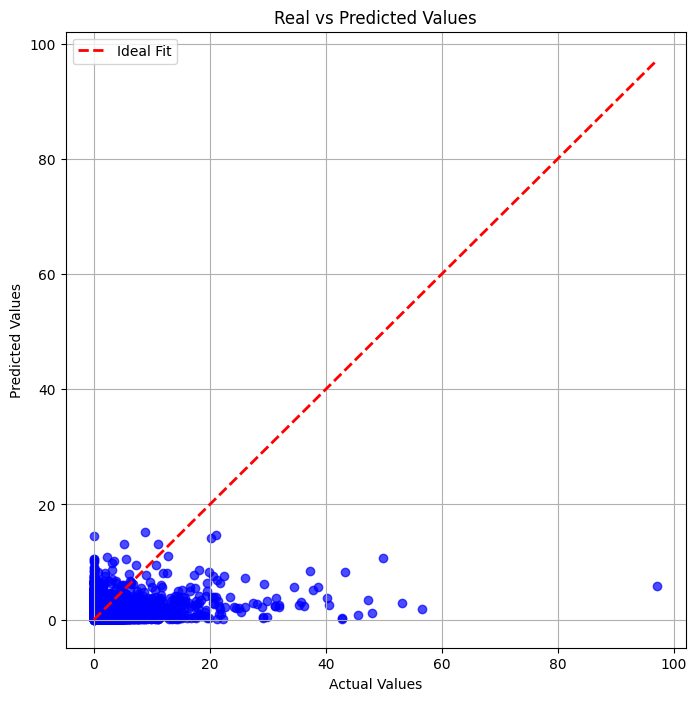

In [15]:
plot_real_vs_predicted(y_test, prec_predictions, save=r'C:\experimento2\Comparative-study-ML-models\figuras\xgb_prec_real_vs_predicted_bases_integradas.png')


The model exhibits a strong bias toward low precipitation values, systematically underestimating moderate and extreme rainfall events. This behavior indicates that the model has learned the dominant distribution of the dataset rather than the underlying physical processes associated with precipitation formation.

The current model does NOT understand the physics of rain

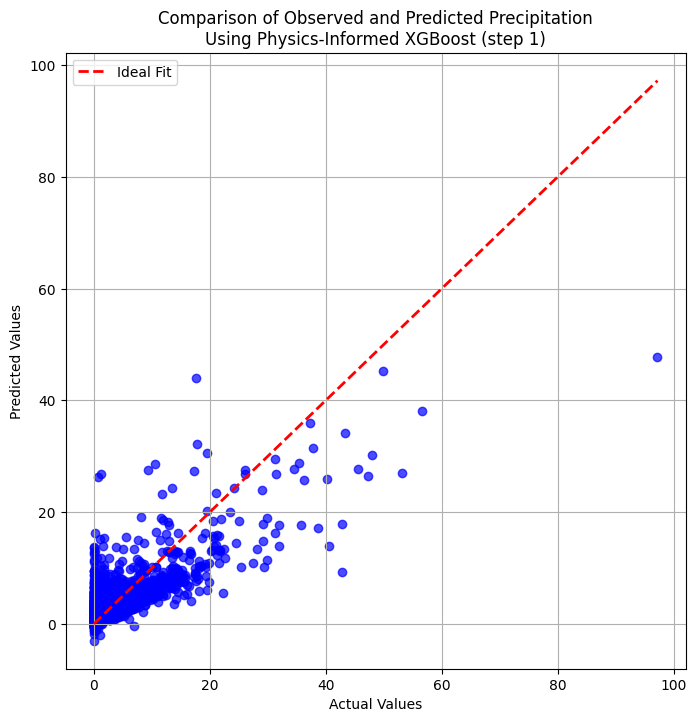

In [27]:
plot_real_vs_predicted(y_test, prec_predictions, save=r'C:\experimento2\Comparative-study-ML-models\figuras\xgb_prec_real_vs_predicted_bases_integradas_piml.png')


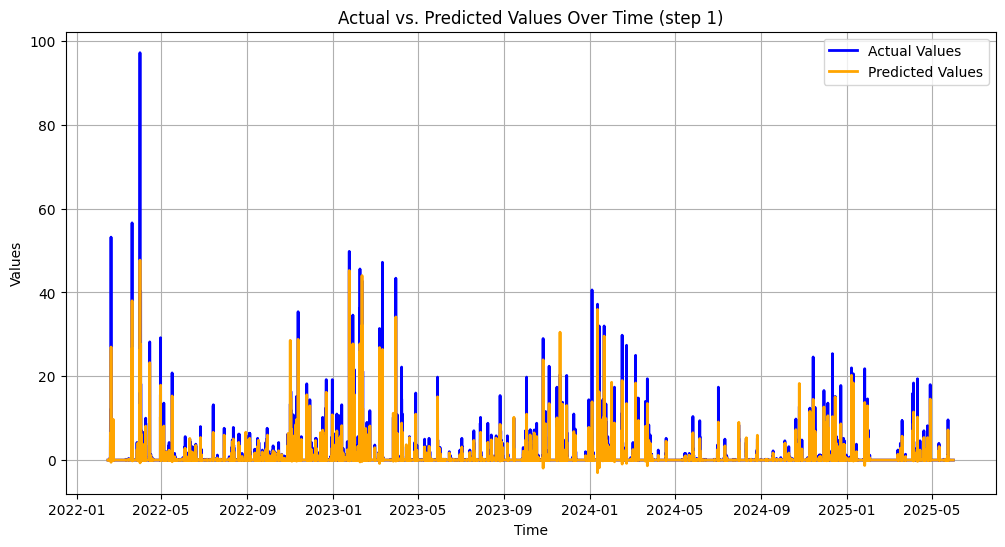

In [29]:
plot_prediction_over_time(y_test, prec_predictions, timestamps_test)


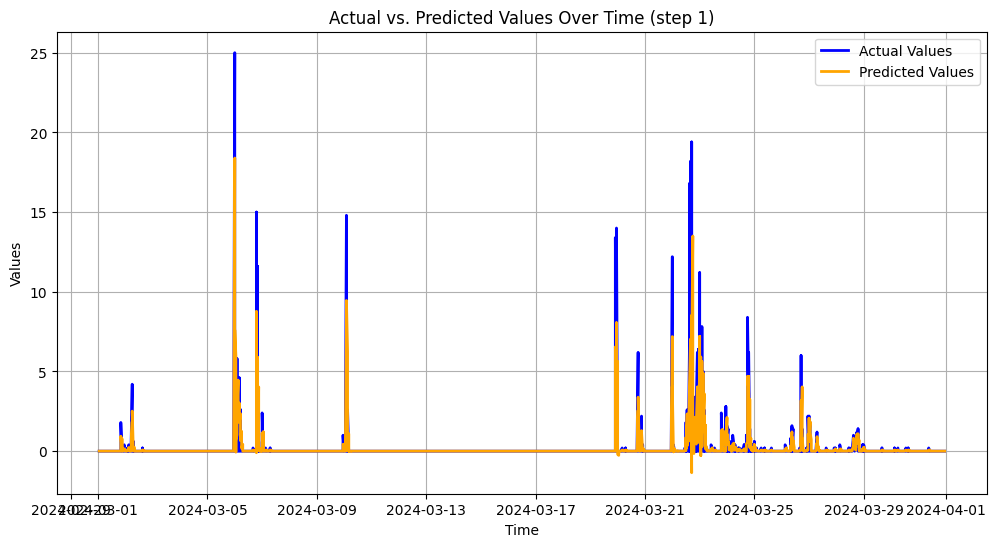

In [30]:
start_date = "2024-03-01 01:00:00"
end_date = "2024-03-31 23:00:00"

plot_prediction_over_time(y_test, prec_predictions, timestamps_test, start_date, end_date, save=r'C:\experimento2\Comparative-study-ML-models\figuras\precipitation_march_2024.png')

In [31]:
import matplotlib.dates as mdates

def plot_daily_prediction_march(y_test, predictions, timestamps, start_date=None, end_date=None, save=False):
    timestamps = pd.to_datetime(timestamps)
    data = pd.DataFrame({'Timestamp': timestamps, 'Actual': y_test, 'Predicted': predictions})

    if start_date:
        data = data[data['Timestamp'] >= pd.to_datetime(start_date)]
    if end_date:
        data = data[data['Timestamp'] <= pd.to_datetime(end_date)]

    plt.figure(figsize=(12, 6))
    plt.plot(data['Timestamp'], data['Actual'], label='Actual Values', color='blue', linewidth=2)
    plt.plot(data['Timestamp'], data['Predicted'], label='Predicted Values', color='orange', linewidth=2)
    
    # Ajustes para exibir apenas o dia e definir título internacional
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d')) # Padrão: apenas o número do dia
    plt.title('Actual vs. Predicted Values - March 2024 (step 1)')
    
    plt.xlabel('Day of Month')
    plt.ylabel('Precipitation (mm/h)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if save: 
        plt.savefig(save)
    plt.show()

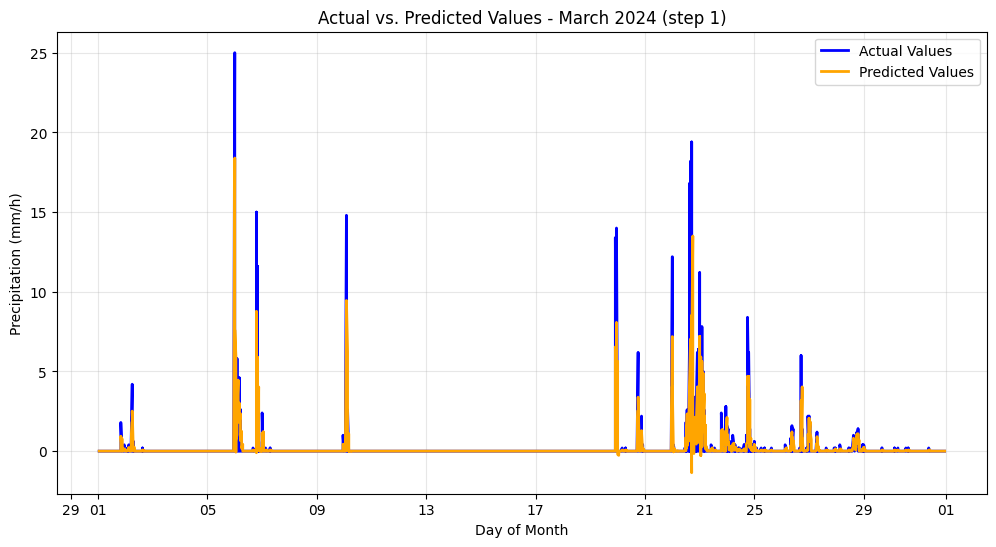

In [32]:
start_date = "2024-03-01 01:00:00"
end_date = "2024-03-31 23:00:00"

# Chamada da nova função
plot_daily_prediction_march(y_test, prec_predictions, timestamps_test, start_date, end_date)

In [21]:
tracker = EmissionsTracker(
    project_name="xgboost shap precipitation 0.8 step1",
    output_file='./codecarbon_emissions_xgboost_piml_steps.csv',
    log_level = "critical"
)

tracker.start()

explainer = shap.Explainer(prec_model, X_train[:100])
shap_values = explainer(X_test)

emissions: float = tracker.stop()
print(f"emissions={emissions}")

 99%|===================| 81830/82964 [00:43<00:00]        

emissions=6.933562782162708e-05


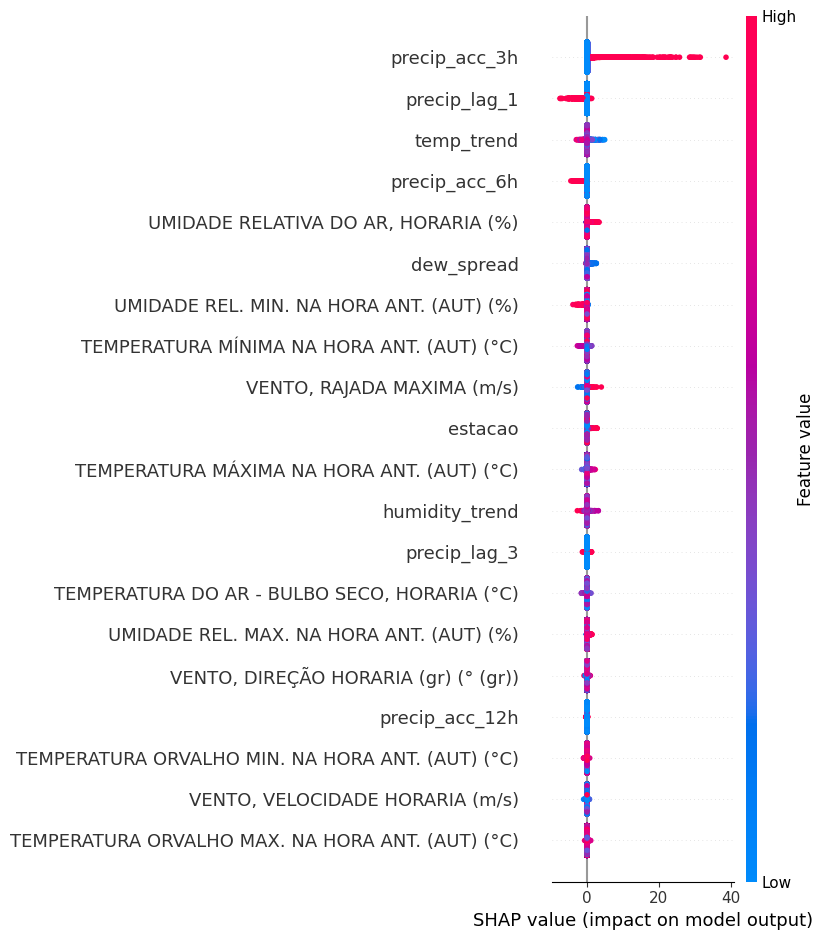

In [22]:
shap.summary_plot(shap_values.values, X_test)

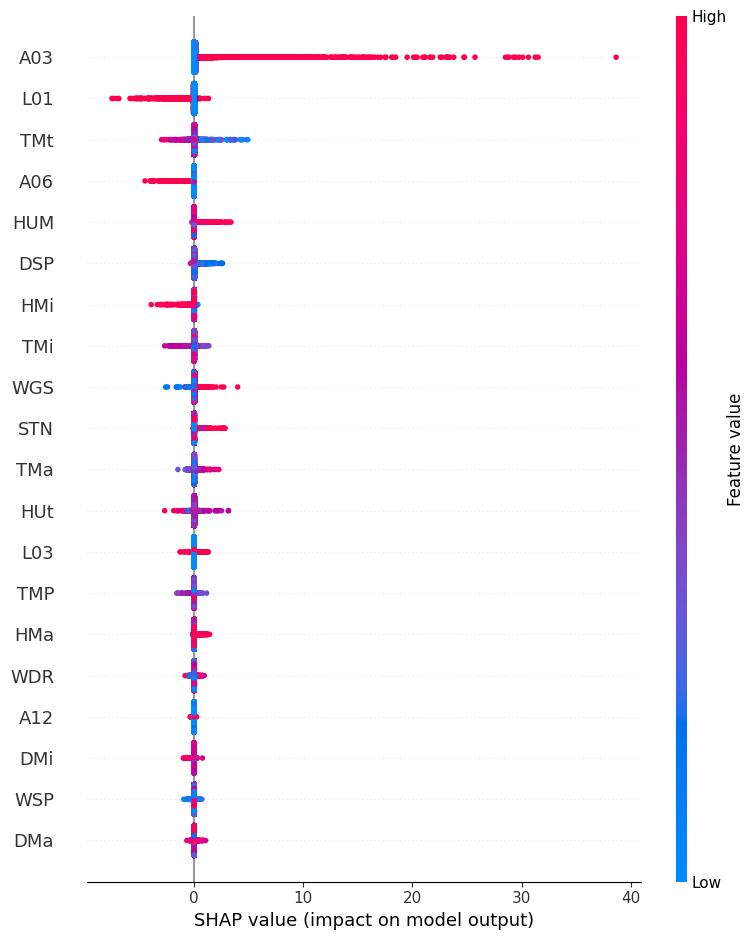

In [23]:
#import shap

# 1. Dicionário de tradução completo (Original + PIML)
code_translation = {
    # Variáveis Originais INMET
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)': 'PRS',
    'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)': 'PRM',
    'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)': 'PRn',
    'RADIACAO GLOBAL (Kj/m²)': 'RAD',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'TMP',
    'TEMPERATURA DO PONTO DE ORVALHO (°C)': 'DWP',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'TMa',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'TMi',
    'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)': 'DMa',
    'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)': 'DMi',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)': 'HMa',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)': 'HMi',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'HUM',
    'VENTO, DIREÇÃO HORARIA (gr) (° (gr))': 'WDR',
    'VENTO, RAJADA MAXIMA (m/s)': 'WGS',
    'VENTO, VELOCIDADE HORARIA (m/s)': 'WSP',
    'estacao': 'STN',

    # Novas Variáveis PIML
    'precip_lag_1': 'L01',
    'precip_lag_3': 'L03',
    'precip_acc_3h': 'A03',
    'precip_acc_6h': 'A06',
    'precip_acc_12h': 'A12',
    'temp_trend': 'TMt',
    'humidity_trend': 'HUt',
    'dew_spread': 'DSP'
}

# 2. Renomeia as colunas do X_test para os códigos curtos
# Certifique-se de usar o X_test que contém as novas colunas PIML
X_test_coded = X_test.rename(columns=code_translation)

# 3. Gera o gráfico Summary Plot padronizado
# Usamos shap_values.values para o gráfico de pontos (Beeswarm)
shap.summary_plot(shap_values.values, X_test_coded)

The SHAP analysis reveals that, although physically meaningful variables such as wind gust and relative humidity are identified as the most influential predictors, their overall contribution remains limited across most observations. This behavior is consistent with the strong class imbalance in the dataset, where the model predominantly learns patterns associated with non-precipitation events.

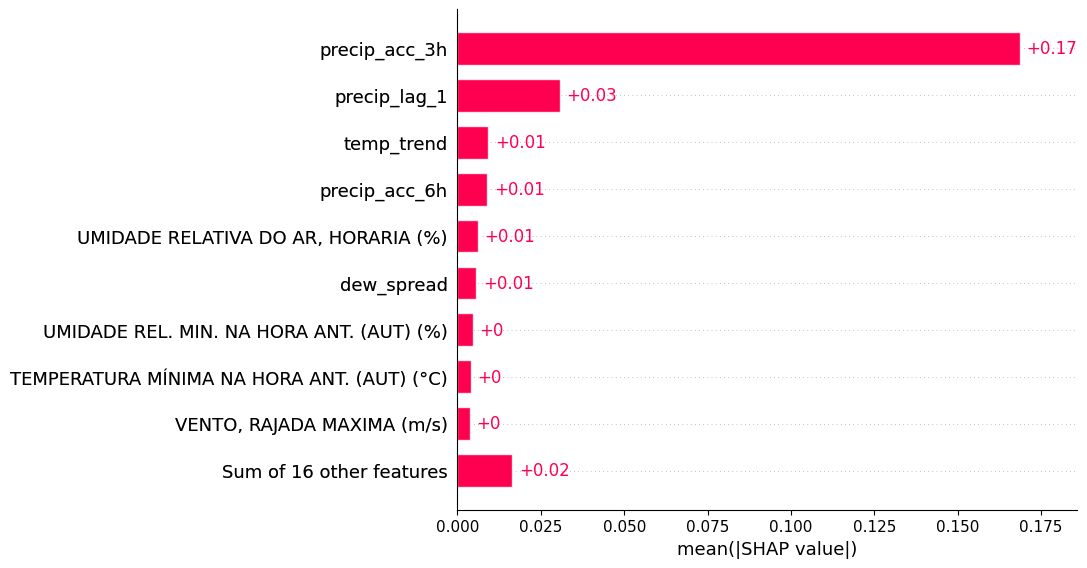

In [24]:
shap.plots.bar(shap_values)

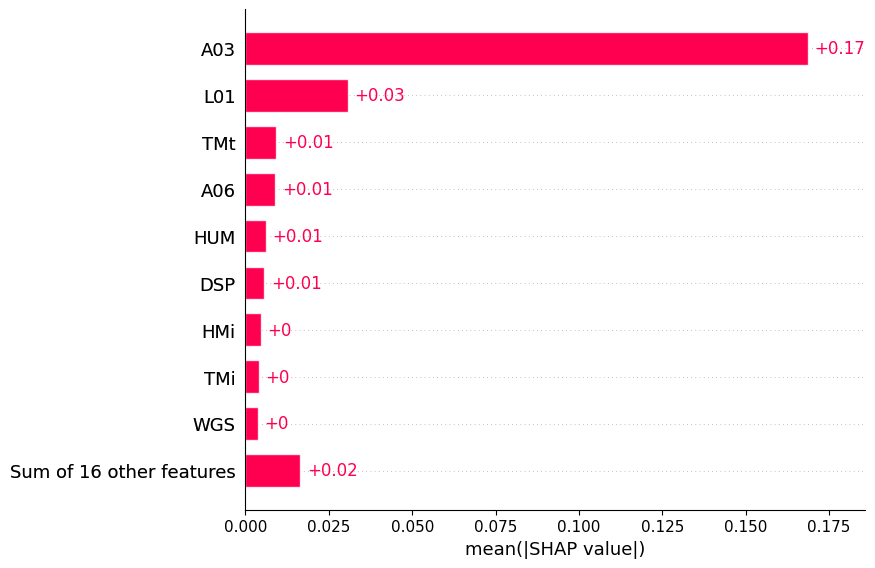

In [25]:
#import shap
import copy

# 1. Dicionário de tradução completo (Original INMET + PIML)
code_translation = {
    # Variáveis Originais INMET
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)': 'PRS',
    'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)': 'PRM',
    'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)': 'PRn',
    'RADIACAO GLOBAL (Kj/m²)': 'RAD',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'TMP',
    'TEMPERATURA DO PONTO DE ORVALHO (°C)': 'DWP',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'TMa',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'TMi',
    'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)': 'DMa',
    'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)': 'DMi',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)': 'HMa',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)': 'HMi',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'HUM',
    'VENTO, DIREÇÃO HORARIA (gr) (° (gr))': 'WDR',
    'VENTO, RAJADA MAXIMA (m/s)': 'WGS',
    'VENTO, VELOCIDADE HORARIA (m/s)': 'WSP',
    'estacao': 'STN',

    # Novas Variáveis PIML (Mapeamento dos nomes técnicos para os códigos)
    'precip_lag_1': 'L01',
    'precip_lag_3': 'L03',
    'precip_acc_3h': 'A03',
    'precip_acc_6h': 'A06',
    'precip_acc_12h': 'A12',
    'temp_trend': 'TMt',
    'humidity_trend': 'HUt',
    'dew_spread': 'DSP'
}

# 2. Cria uma cópia dos valores SHAP para manter o objeto original intacto
shap_values_coded = copy.deepcopy(shap_values)

# 3. Substitui os nomes das colunas pelos códigos dentro do objeto SHAP
# O método percorre os feature_names e aplica o código correspondente
shap_values_coded.feature_names = [code_translation.get(name, name) for name in shap_values_coded.feature_names]

# 4. Gera o gráfico de barras padronizado
shap.plots.bar(shap_values_coded)

The SHAP global importance analysis indicates that wind gust and relative humidity are the dominant predictors of precipitation. However, the relatively low contribution of other meteorological variables suggests that the model captures only a partial representation of the underlying physical processes.

In [34]:
mask = y_test > 25  # heavy rain
rmse_heavy = np.sqrt(mean_squared_error(y_test[mask], prec_predictions[mask]))

mask = y_test > 50  # extreme
rmse_extreme = np.sqrt(mean_squared_error(y_test[mask], prec_predictions[mask]))

print(rmse_heavy, rmse_extreme)

17.749942901941886 34.06891004403605


temperatura xgboost

In [17]:
X_train, X_test, y_train, y_test = split_train_test(X_temp, y_temp, 0.8)

tracker = EmissionsTracker(
    project_name="xgboost temperature train 0.8",
    output_file='./codecarbon_emissions_xgboost.csv',
    log_level = "critical"
)

tracker.start()

temp_model, temp_predictions, temp_best_params = grid_search_xgboost(X_train, y_train, X_test, y_test)

emissions: float = tracker.stop()
print(f"emissions={emissions}")

Grid Search Progress: 100%|██████████| 243/243 [02:08<00:00,  1.90it/s]


Best parameters found:
{'device': 'cuda', 'tree_method': 'hist', 'max_depth': 6, 'eta': 0.1, 'subsample': 1.0, 'colsample_bytree': 0.6, 'min_child_weight': 3, 'objective': 'reg:squarederror', 'eval_metric': 'rmse'}
Best RMSE: 2.3122773644776036
emissions=0.0020118761540473453


In [18]:
evaluate_model(y_test, temp_predictions)

MAE: 1.8099716228671687
MSE: 5.346626610275493
MRSE: 2.3122773644776036


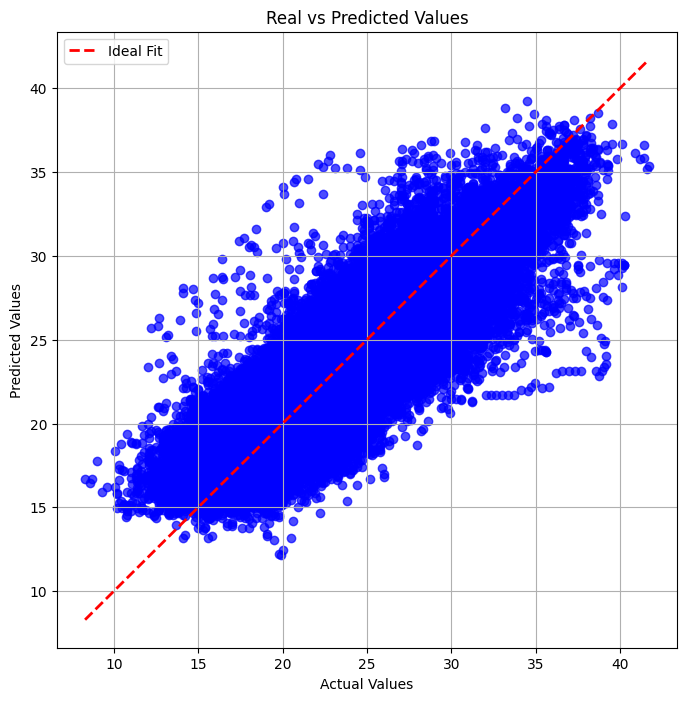

In [19]:
plot_real_vs_predicted(y_test, temp_predictions, save=r'C:\Users\User\Documents\Estacoes-Meteorologicas-RJ\plots\xgb_temp_real_vs_predicted_bases_integradas.png')


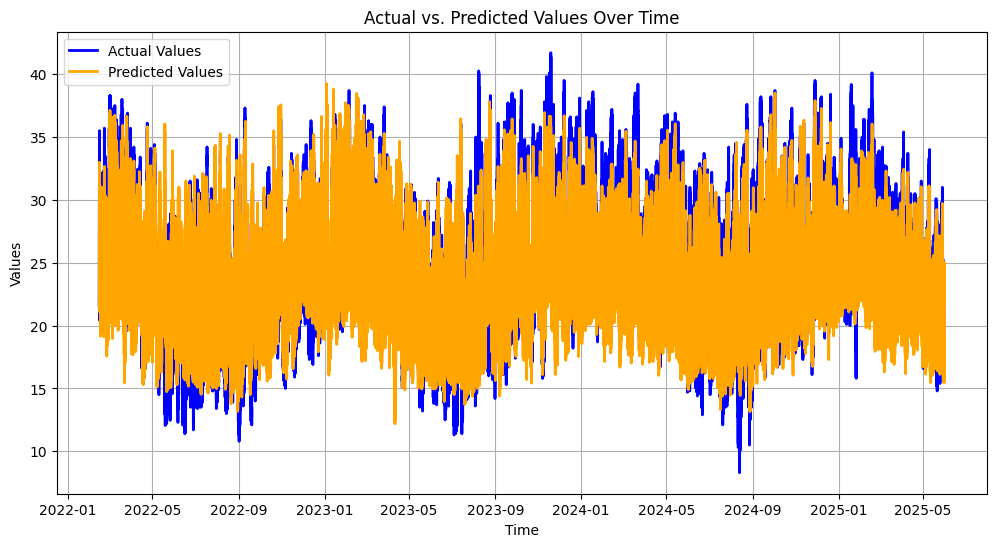

In [20]:
plot_prediction_over_time(y_test, temp_predictions, timestamps_test)

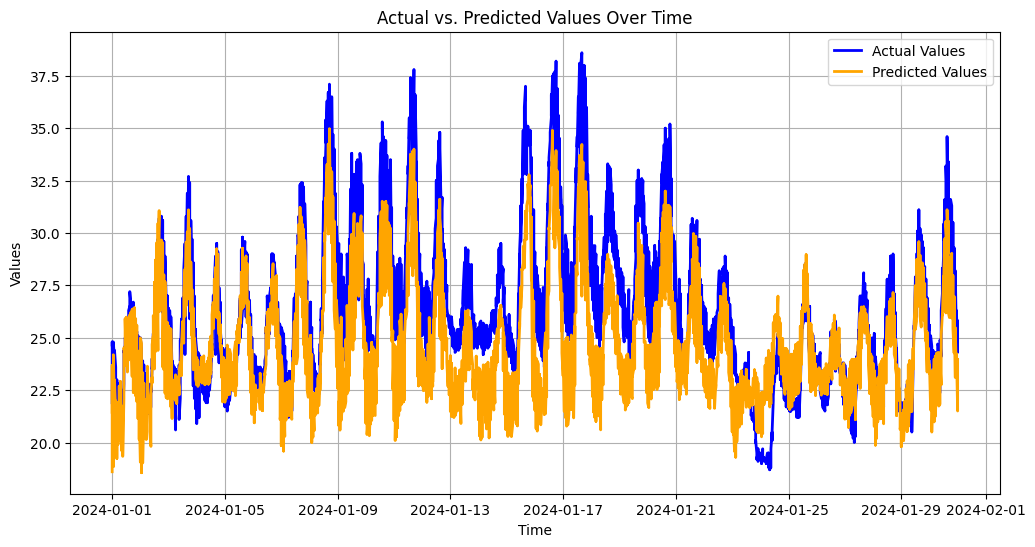

In [21]:
start_date = "2024-01-01"
end_date = "2024-01-31"

plot_prediction_over_time(y_test, temp_predictions, timestamps_test, start_date, end_date, save=r'C:\Users\User\Documents\Estacoes-Meteorologicas-RJ\plots\xgb_temperature_january_2024.png')

In [22]:
tracker = EmissionsTracker(
    project_name="xgboost shap temperature 0.8",
    output_file='./codecarbon_emissions_xgboost.csv',
    log_level = "critical"
)

tracker.start()

explainer = shap.Explainer(temp_model, X_train[:100])
shap_values = explainer(X_test)

emissions: float = tracker.stop()
print(f"emissions={emissions}")

100%|===================| 82965/82966 [03:05<00:00]        

emissions=0.002563609051413541


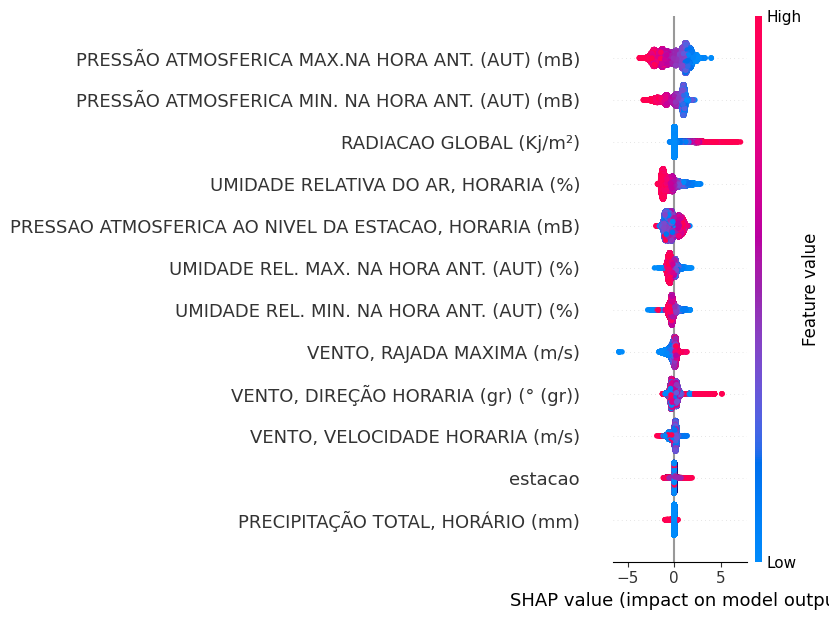

In [23]:
shap.summary_plot(shap_values.values, X_test)

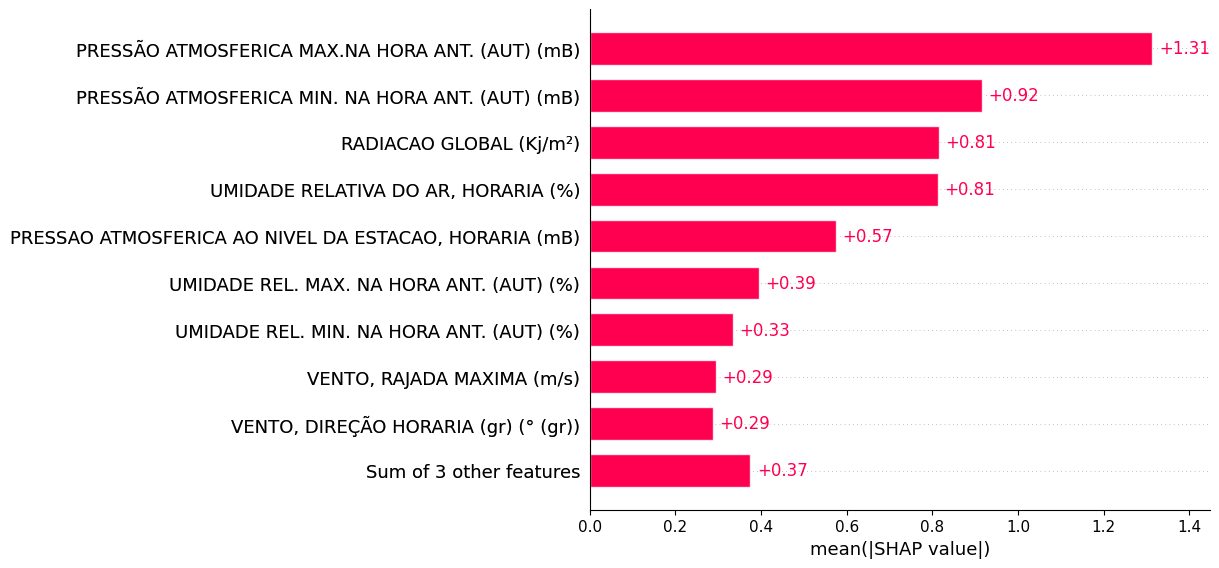

In [24]:
shap.plots.bar(shap_values)

umidade xgboost

In [25]:
X_train, X_test, y_train, y_test = split_train_test(X_umid, y_umid, 0.8)

tracker = EmissionsTracker(
    project_name="xgboost umidity train 0.8",
    output_file='./codecarbon_emissions_xgboost.csv',
    log_level = "critical"
)

tracker.start()

umid_model, umid_predictions, umid_best_params = grid_search_xgboost(X_train, y_train, X_test, y_test)

emissions: float = tracker.stop()
print(f"emissions={emissions}")

Grid Search Progress: 100%|██████████| 243/243 [02:12<00:00,  1.84it/s]


Best parameters found:
{'device': 'cuda', 'tree_method': 'hist', 'max_depth': 8, 'eta': 0.1, 'subsample': 1.0, 'colsample_bytree': 0.6, 'min_child_weight': 1, 'objective': 'reg:squarederror', 'eval_metric': 'rmse'}
Best RMSE: 8.141655677384767
emissions=0.0020836928127094434


In [26]:
evaluate_model(y_test, umid_predictions)

MAE: 3.7607618784443875
MSE: 66.28655716909161
MRSE: 8.141655677384767


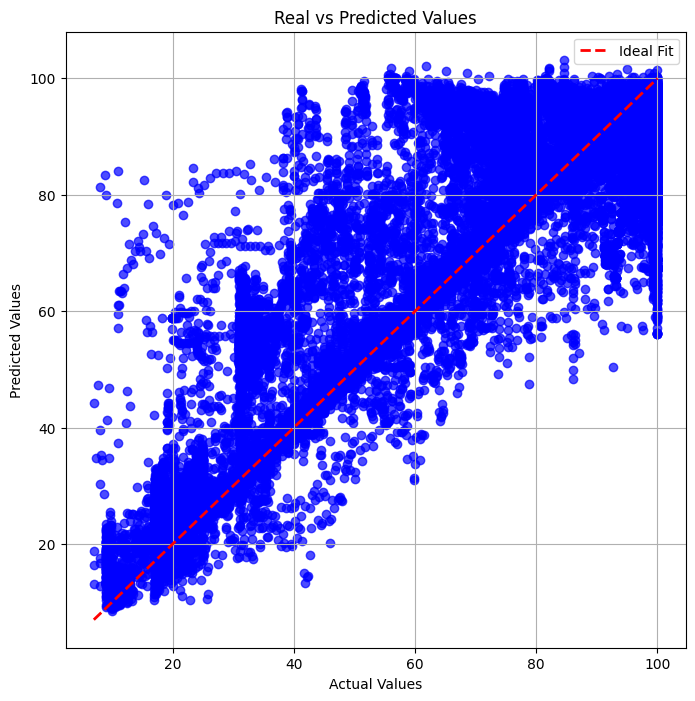

In [27]:
plot_real_vs_predicted(y_test, umid_predictions, save=r'C:\Users\User\Documents\Estacoes-Meteorologicas-RJ\plots\xgb_umid_real_vs_predicted_bases_integradas.png')


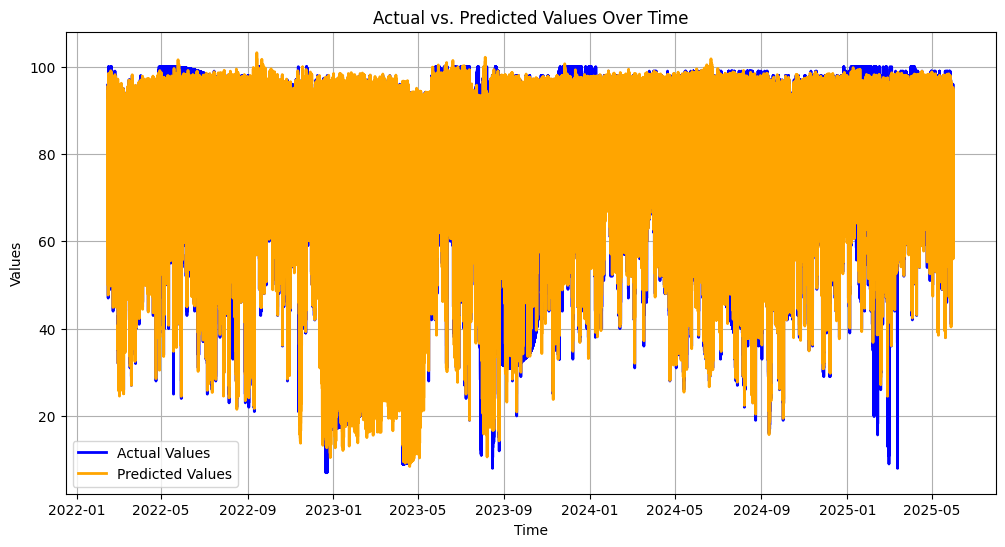

In [28]:
plot_prediction_over_time(y_test, umid_predictions, timestamps_test)

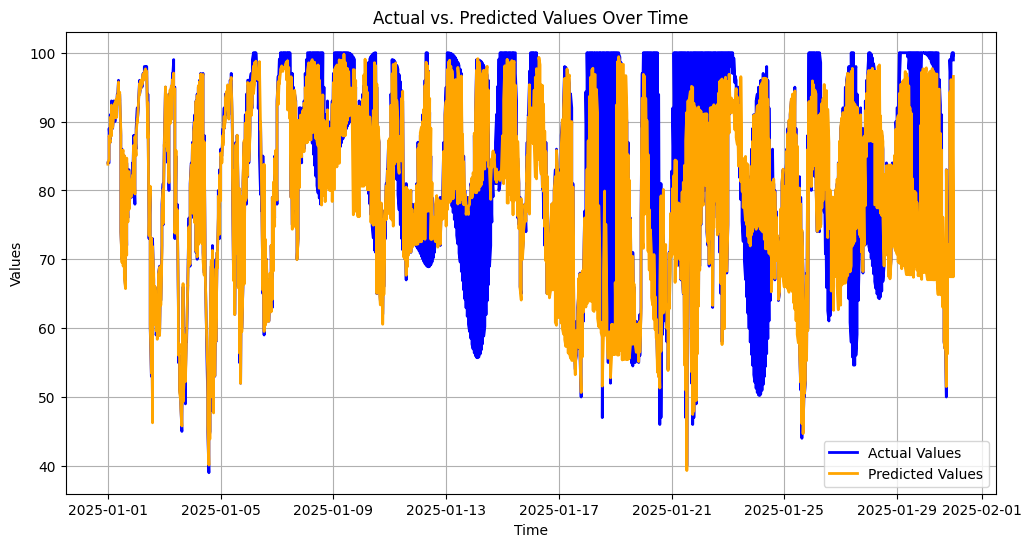

In [29]:
start_date = "2025-01-01"
end_date = "2025-01-31"

plot_prediction_over_time(y_test, umid_predictions, timestamps_test, start_date, end_date, save=r'C:\Users\User\Documents\Estacoes-Meteorologicas-RJ\plots\xgb_umid_real_2025-01_bases_integradas.png')

In [30]:
tracker = EmissionsTracker(
    project_name="xgboost shap humidity 0.8",
    output_file='./codecarbon_emissions_xgboost.csv',
    log_level = "critical"
)

tracker.start()


explainer = shap.Explainer(umid_model, X_train[:100])
shap_values = explainer(X_test)

emissions: float = tracker.stop()
print(f"emissions={emissions}")

100%|===================| 82936/82966 [07:53<00:00]        

emissions=0.006527731366665419


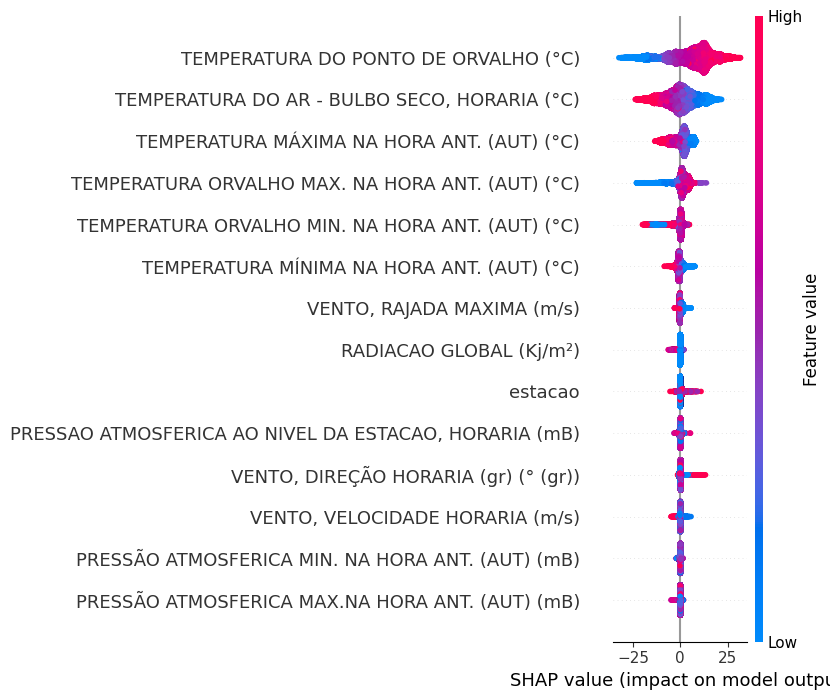

In [31]:
shap.summary_plot(shap_values.values, X_test)

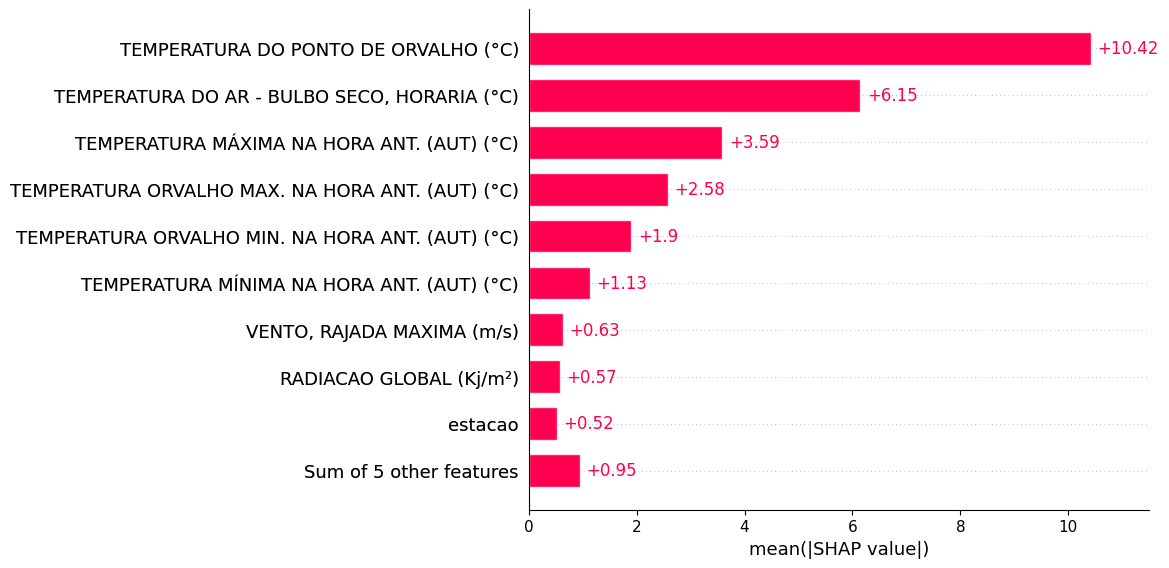

In [32]:
shap.plots.bar(shap_values)